<a href="https://colab.research.google.com/github/vk001king/qt/blob/main/notebooks/qt_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QT - Quantum Turbulence in a Dipolar Supersolid

Validated eGPE split-step solver.

**How to use:** `Runtime -> Run all`.  Nothing to edit.

Every output is written to Google Drive under
`MyDrive/Research/Quantum_Turbulence/<date>_<time>_<title>/`
with subfolders `checkpoints/ diagnostics/ figures/ logs/`.

Total run time is roughly 6-10 minutes.

## 1. Setup - clone, import, mount Drive

In [1]:
# CELL 1 - Setup.  Run this first.  No edits needed.
import os, sys, subprocess

REPO = 'https://github.com/vk001king/qt.git'
DEST = '/content/qt'

# --- clone or update ------------------------------------------------
if os.path.isdir(DEST + '/.git'):
    print('Repo present; pulling latest...')
    subprocess.run(['git', '-C', DEST, 'pull', '-q'], check=False)
else:
    print('Cloning', REPO)
    r = subprocess.run(['git', 'clone', '-q', REPO, DEST],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError('git clone failed:\n' + r.stderr)
print('Repo ready at', DEST)

# --- verify the package files are actually present -------------------
need = ['__init__.py', 'kernels.py', 'lhy.py', 'solver.py',
        'diagnostics.py', 'drive_io.py']
have = os.listdir(DEST + '/qtsim')
missing = [f for f in need if f not in have]
if missing:
    raise RuntimeError('Repo incomplete, missing: %s' % missing)
print('All 6 package files present')

# --- put the repo first on the import path, clear stale modules ------
if DEST in sys.path:
    sys.path.remove(DEST)
sys.path.insert(0, DEST)
for m in [k for k in sys.modules if k.split('.')[0] == 'qtsim']:
    del sys.modules[m]

# --- import and self-check ------------------------------------------
import qtsim
from qtsim import Grid, EGPESolver, Archive
assert qtsim.selfcheck(), 'qtsim self-check failed'
print('Loaded qtsim from', os.path.dirname(qtsim.__file__))

# --- mount Drive, build folder tree ---------------------------------
archive = Archive(base='Research', project='Quantum_Turbulence')
archive.list_runs()

Cloning https://github.com/vk001king/qt.git
Repo ready at /content/qt
All 6 package files present
  [ OK ] qtsim v1.0.0: 15 public names available
Loaded qtsim from /content/qt/qtsim
Preparing archive tree...
  Not running in Colab -> using local root: /content/drive_local
  [created] /content/drive_local
  [created] /content/drive_local/Research
  [created] /content/drive_local/Research/Quantum_Turbulence
  [created] _ARCHIVE_INDEX.json
Archive ready: /content/drive_local/Research/Quantum_Turbulence

No runs recorded yet.


[]

## 2. Validation - 18 checks against analytic results

Every check compares the solver to something known exactly.
If any fails, stop: the physics below cannot be trusted.

In [2]:
# CELL 2 - Validation suite (18 checks).  Takes about 60 s.
import subprocess, sys

run = archive.new_run('validation suite',
                      params={'version': qtsim.__version__})
r = subprocess.run([sys.executable, 'tests/run_validation.py'],
                   cwd=DEST, capture_output=True, text=True)
print(r.stdout[-3000:])
if r.stderr.strip():
    print('STDERR:', r.stderr[-1500:])

run.save_text(r.stdout, 'validation-output')
if r.returncode == 0:
    run.finish('completed')
    print('RESULT: all checks passed - solver is trustworthy')
else:
    run.finish('failed')
    print('RESULT: failures above - do not run science yet')

Creating run folder for 'validation suite':
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1623_validation-suite
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1623_validation-suite/checkpoints
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1623_validation-suite/diagnostics
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1623_validation-suite/figures
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1623_validation-suite/logs
Run folder ready: /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1623_validation-suite

[PASS] T1 plane-wave max error: 2.082e-13  (criterion: < 1e-10)
[PASS] T2 Strang error ratio e(4dt)/e(2dt): 5.000  (criterion: 5.0 +/- 0.5 (2nd order, dt/4 ref))
[PASS] T3 stationarity residual: 3.691e-06  (criterion: < 1e-5)
[PASS] T3 interior rms(n - n_TF)/n_peak: 1.386e-03  (criterion: < 3e-2 (TF regime))
[PASS] T3 |mu - mu_TF|/mu_TF: 2.657e-0

## 3. Vortex pair - detection and sound emission

A vortex and antivortex are imprinted, relaxed, then evolved.
Watch incompressible (vortex) energy convert into compressible
(sound) energy as the pair annihilates.

Creating run folder for 'vortex pair dynamics':
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics/checkpoints
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics/diagnostics
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics/figures
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics/logs
Run folder ready: /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics

vortices detected: +1 = 1  -1 = 1
    saved figure -> pair-initial.png


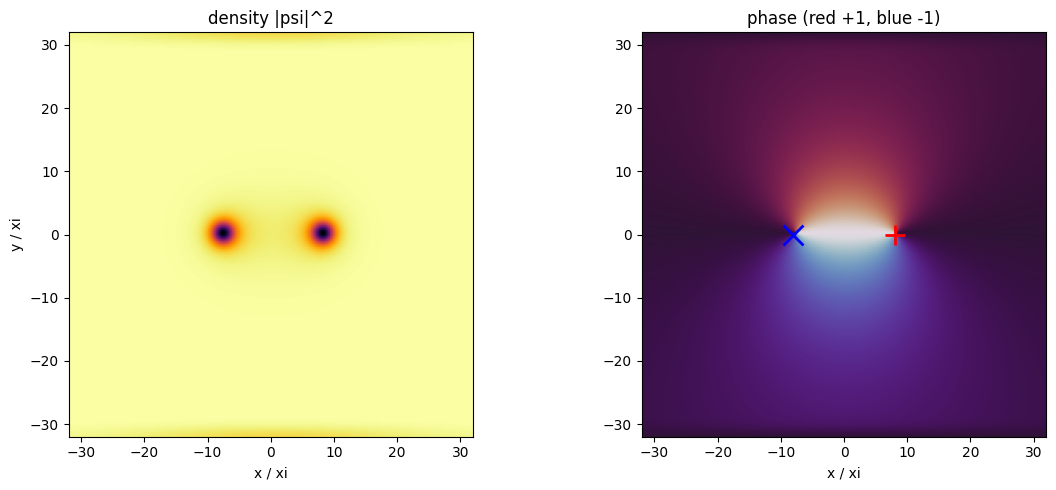

t =    0.0  nv =  2  Ei =  126.880  Ec =   28.531
t =   20.0  nv =  2  Ei =  124.387  Ec =   13.842
t =   40.0  nv = 338  Ei = 23415.408  Ec = 389614.687
t =   60.0  nv = 20032  Ei = 439538.752  Ec = 416944.699
t =   80.0  nv = 21080  Ei = 484101.668  Ec = 409247.748
    saved figure -> energy-channels.png


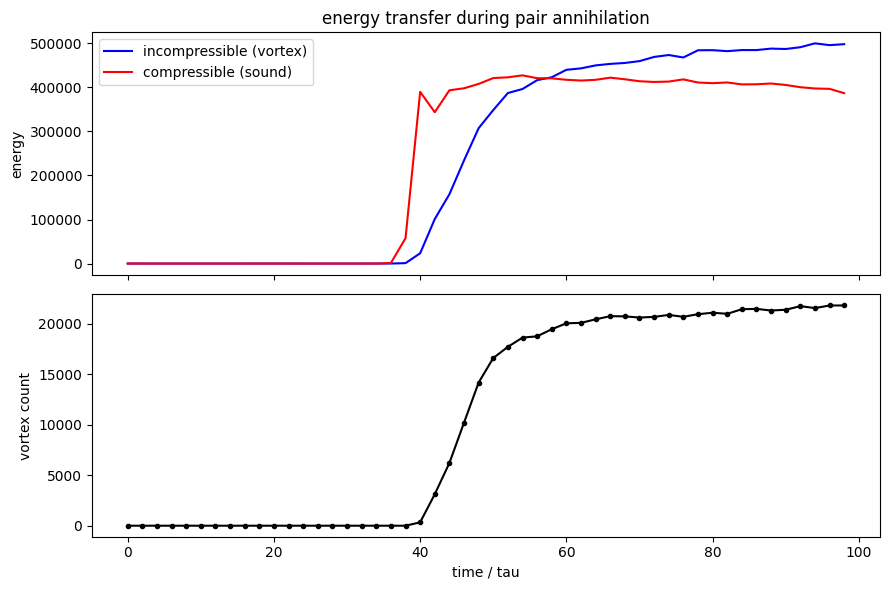

    saved diagnostics -> diagnostics.json (50 record(s))

Run 'vortex pair dynamics' completed in 57.6 s
  Folder: /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1624_vortex-pair-dynamics


In [3]:
# CELL 3 - Vortex pair: detection, evolution, energy channels.
import numpy as np, matplotlib.pyplot as plt
from qtsim import Grid, EGPESolver
from qtsim import plaquette_charges_2d, helmholtz_split_2d

run = archive.new_run('vortex pair dynamics',
                      params={'N': 256, 'L': 64.0, 'dt': 0.02})

N, L = 256, 64.0
grid = Grid((N, N), (L, L))
dx = grid.dx[0]
# half-cell offsets keep cores off grid lines (phase is undefined there)
xp, xm, yc = 8.0 + 0.5*dx, -8.0 + 0.5*dx, 0.5*dx
thp = np.arctan2(grid.X[1] - yc, grid.X[0] - xp)
thm = np.arctan2(grid.X[1] - yc, grid.X[0] - xm)
rp = np.sqrt((grid.X[0] - xp)**2 + (grid.X[1] - yc)**2)
rm = np.sqrt((grid.X[0] - xm)**2 + (grid.X[1] - yc)**2)

s = EGPESolver(grid)
s.psi = np.tanh(rp) * np.tanh(rm) * np.exp(1j*(thp - thm))
s.step_imag(5e-3, 200, norm_target=s.norm())

q = plaquette_charges_2d(s.psi)
npos, nneg = int((q == 1).sum()), int((q == -1).sum())
print('vortices detected: +1 =', npos, ' -1 =', nneg)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(np.abs(s.psi).T**2, origin='lower',
             extent=[-L/2, L/2, -L/2, L/2], cmap='inferno')
ax[0].set_title('density |psi|^2')
ax[0].set_xlabel('x / xi'); ax[0].set_ylabel('y / xi')
ax[1].imshow(np.angle(s.psi).T, origin='lower',
             extent=[-L/2, L/2, -L/2, L/2], cmap='twilight')
for v in np.argwhere(q == 1):
    ax[1].plot(grid.X[0][v[0], v[1]], grid.X[1][v[0], v[1]],
               'r+', ms=14, mew=2)
for v in np.argwhere(q == -1):
    ax[1].plot(grid.X[0][v[0], v[1]], grid.X[1][v[0], v[1]],
               'bx', ms=14, mew=2)
ax[1].set_title('phase (red +1, blue -1)')
ax[1].set_xlabel('x / xi')
plt.tight_layout()
run.save_figure(fig, 'pair-initial')
plt.show()

dt = 0.02
ts, Ei_s, Ec_s, nv_s = [], [], [], []
for k in range(5000):
    s.step_real(dt)
    if k % 100 == 0:
        Ei, Ec, _ = helmholtz_split_2d(s.psi, grid)
        nv = int((plaquette_charges_2d(s.psi) != 0).sum())
        ts.append(k*dt); Ei_s.append(Ei); Ec_s.append(Ec); nv_s.append(nv)
        if k % 1000 == 0:
            print('t = %6.1f  nv = %2d  Ei = %8.3f  Ec = %8.3f'
                  % (k*dt, nv, Ei, Ec))

fig2, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(ts, Ei_s, 'b-', label='incompressible (vortex)')
a1.plot(ts, Ec_s, 'r-', label='compressible (sound)')
a1.set_ylabel('energy'); a1.legend()
a1.set_title('energy transfer during pair annihilation')
a2.plot(ts, nv_s, 'ko-', ms=3)
a2.set_xlabel('time / tau'); a2.set_ylabel('vortex count')
plt.tight_layout()
run.save_figure(fig2, 'energy-channels')
plt.show()

run.save_diagnostics([{'t': a, 'Ei': b, 'Ec': c, 'nv': d}
                      for a, b, c, d in zip(ts, Ei_s, Ec_s, nv_s)])
run.finish('completed')

## 4. Dipolar ground state

Imaginary-time relaxation with the dipolar kernel and the
Lee-Huang-Yang term, then a density-contrast test.

Creating run folder for 'dipolar groundstate':
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate/checkpoints
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate/diagnostics
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate/figures
  [created] /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate/logs
Run folder ready: /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate

eps_dd = 1.40   Q5 = 4.1536   gamma_tilde = 0.176753
relaxing in imaginary time...
mu = 1.17587   residual = 1.40e-02
density contrast = 0.369  ->  MODULATED (supersolid-like)
    saved figure -> groundstate-density.png


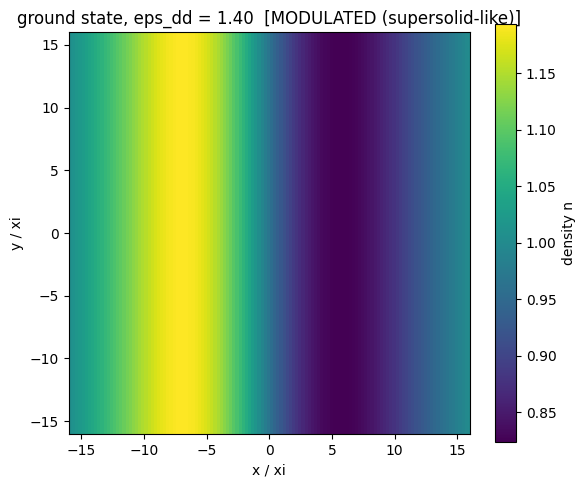

    saved checkpoint -> ckpt_step00008000_t000000.00_162554.npz
    saved diagnostics -> diagnostics.json (1 record(s))

Run 'dipolar groundstate' completed in 22.0 s
  Folder: /content/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_dipolar-groundstate

NOTE: this 2D kernel is a demonstration, not the production
quasi-2D projected kernel (see FLAGS.md).  Reproducing the
published Dy lattice constant is validation rung V4.


In [4]:
# CELL 4 - Dipolar ground state.  Takes about 90 s.
import numpy as np, matplotlib.pyplot as plt
from qtsim import Grid, EGPESolver, bare_dipolar_symbol, gamma_tilde, Q5

eps_dd, n0as3 = 1.4, 5e-5
run = archive.new_run('dipolar groundstate',
                      params={'eps_dd': eps_dd, 'n0_as3': n0as3, 'N': 128})

grid = Grid((128, 128), (32.0, 32.0))
gam = gamma_tilde(eps_dd, n0as3)
# 2D: dipoles polarized IN-PLANE.  A truncated 3D axis (0,0,1)->(0,0)
# would be the zero vector and give NaN everywhere.
Dk = bare_dipolar_symbol(grid, (0, 1))
print('eps_dd = %.2f   Q5 = %.4f   gamma_tilde = %.6f'
      % (eps_dd, Q5(eps_dd), gam))

rng = np.random.default_rng(42)
s = EGPESolver(grid, eps_dd=eps_dd, gamma=gam, Dk=Dk)
s.psi = (np.ones(grid.shape, dtype=complex)
         + 0.05*(rng.standard_normal(grid.shape)
                 + 1j*rng.standard_normal(grid.shape)))
Nt = float(grid.integrate(np.ones(grid.shape)))
s.psi *= np.sqrt(Nt / s.norm())

print('relaxing in imaginary time...')
s.step_imag(0.005, 4000, norm_target=Nt)
s.step_imag(0.001, 4000, norm_target=Nt)
mu, res = s.mu_and_residual()
print('mu = %.5f   residual = %.2e' % (mu, res))

n = np.abs(s.psi)**2
contrast = float((n.max() - n.min()) / n.mean())
phase = 'MODULATED (supersolid-like)' if contrast > 0.10 else 'UNIFORM'
print('density contrast = %.3f  ->  %s' % (contrast, phase))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(n.T, origin='lower', extent=[-16, 16, -16, 16],
               cmap='viridis')
plt.colorbar(im, label='density n')
ax.set_title('ground state, eps_dd = %.2f  [%s]' % (eps_dd, phase))
ax.set_xlabel('x / xi'); ax.set_ylabel('y / xi')
plt.tight_layout()
run.save_figure(fig, 'groundstate-density')
plt.show()

run.save_checkpoint(s.psi, step=8000, t=0.0)
run.save_diagnostics([{'eps_dd': eps_dd, 'mu': mu, 'residual': res,
                       'contrast': contrast, 'phase': phase}])
run.finish('completed')

print()
print('NOTE: this 2D kernel is a demonstration, not the production')
print('quasi-2D projected kernel (see FLAGS.md).  Reproducing the')
print('published Dy lattice constant is validation rung V4.')

## 5. Campaign run

Ground state, stirring, free decay - checkpointed to Drive.

In [5]:
# CELL 5 - Short campaign run through the archive.
import subprocess, sys

cmd = [sys.executable, 'campaign/template_scan.py',
       '--eps_dd', '1.3', '--Ma', '0.5', '--seed', '0',
       '--N', '128', '--L', '64',
       '--T_relax', '20', '--T_stir', '20', '--T_decay', '40',
       '--checkpoint_every', '200', '--use_archive']
r = subprocess.run(cmd, cwd=DEST, capture_output=True, text=True)
print(r.stdout[-2500:])
if r.stderr.strip():
    print('STDERR:', r.stderr[-1200:])

=== SSQT campaign run: eps_dd=1.3, Ma=0.5, seed=0 ===
Preparing archive tree...
  Not running in Colab -> using local root: /content/qt/drive_local
  [created] /content/qt/drive_local
  [created] /content/qt/drive_local/Research
  [created] /content/qt/drive_local/Research/Quantum_Turbulence
  [created] _ARCHIVE_INDEX.json
Archive ready: /content/qt/drive_local/Research/Quantum_Turbulence

Creating run folder for 'stirred tangle eps1.30 Ma0.50 seed0':
  [created] /content/qt/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_stirred-tangle-eps1.30-ma0.50-seed0
  [created] /content/qt/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_stirred-tangle-eps1.30-ma0.50-seed0/checkpoints
  [created] /content/qt/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_stirred-tangle-eps1.30-ma0.50-seed0/diagnostics
  [created] /content/qt/drive_local/Research/Quantum_Turbulence/2026-08-04_1625_stirred-tangle-eps1.30-ma0.50-seed0/figures
  [created] /content/qt/drive_local/Research/Qua

## 6. Archive contents

In [6]:
# CELL 6 - Everything saved in Drive, run by run.
import os

print('=' * 62)
archive.list_runs()
print('=' * 62)

for r in archive.load_index().get('runs', []):
    d = os.path.join(archive.project_dir, r['run_id'])
    print()
    print(r['run_id'])
    print('   title   :', r.get('title', '?'))
    print('   started :', r.get('started', '?'))
    print('   status  :', r.get('status', '?'))
    if r.get('parameters'):
        print('   params  :', r['parameters'])
    for sub in ('checkpoints', 'diagnostics', 'figures', 'logs'):
        p = os.path.join(d, sub)
        if not os.path.isdir(p):
            continue
        for f in sorted(os.listdir(p)):
            kb = os.path.getsize(os.path.join(p, f)) / 1024.0
            print('     %s/%s  (%.1f KB)' % (sub, f, kb))

print()
print('Drive location: MyDrive/Research/Quantum_Turbulence/')

3 run(s) in /content/drive_local/Research/Quantum_Turbulence:

  2026-08-04T16:23:20  [completed]  validation suite
      folder: 2026-08-04_1623_validation-suite
  2026-08-04T16:24:34  [completed]  vortex pair dynamics
      folder: 2026-08-04_1624_vortex-pair-dynamics
  2026-08-04T16:25:32  [completed]  dipolar groundstate
      folder: 2026-08-04_1625_dipolar-groundstate

2026-08-04_1623_validation-suite
   title   : validation suite
   started : 2026-08-04T16:23:20
   status  : completed
   params  : {'version': '1.0.0'}
     logs/validation-output.txt  (1.5 KB)

2026-08-04_1624_vortex-pair-dynamics
   title   : vortex pair dynamics
   started : 2026-08-04T16:24:34
   status  : completed
   params  : {'N': 256, 'L': 64.0, 'dt': 0.02}
     diagnostics/diagnostics.json  (4.3 KB)
     figures/energy-channels.png  (75.4 KB)
     figures/pair-initial.png  (167.5 KB)

2026-08-04_1625_dipolar-groundstate
   title   : dipolar groundstate
   started : 2026-08-04T16:25:32
   status  : comple